In [2]:
import pandas as pd

df = pd.read_csv("cleaned_visa_Feature_engineered_dataset.csv")

df.head()

,CASE_STATUS,VISA_CLASS,JOB_TITLE,FULL_TIME_POSITION,EMPLOYER_STATE,WORKSITE_STATE,WAGE_RATE_OF_PAY_FROM,PREVAILING_WAGE,processing_days,wage_ratio,application_month,state_processing_avg,worksite_processing_avg
0,0,1,1009,1,34,10,-0.278511,-0.251113,5,1.109109,9,16.459202,22.462290
1,0,1,12013,1,24,23,-0.734014,-1.037296,5,0.707622,9,40.323003,37.431016
2,0,1,10836,1,9,20,-0.685448,-0.960521,5,0.713621,9,19.781505,30.470095
3,0,1,27577,1,25,24,-0.734281,-1.095813,5,0.670079,9,23.065644,22.700271
4,0,1,42658,1,47,45,-0.554148,-0.682077,5,0.812441,9,23.650974,19.195931


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200998 entries, 0 to 200997
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   CASE_STATUS              200998 non-null  int64  
 1   VISA_CLASS               200998 non-null  int64  
 2   JOB_TITLE                200998 non-null  int64  
 3   FULL_TIME_POSITION       200998 non-null  int64  
 4   EMPLOYER_STATE           200998 non-null  int64  
 5   WORKSITE_STATE           200998 non-null  int64  
 6   WAGE_RATE_OF_PAY_FROM    200998 non-null  float64
 7   PREVAILING_WAGE          200998 non-null  float64
 8   processing_days          200998 non-null  int64  
 9   wage_ratio               200998 non-null  float64
 10  application_month        200998 non-null  int64  
 11  state_processing_avg     200998 non-null  float64
 12  worksite_processing_avg  200998 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 19.9 MB


In [4]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [5]:
X = df.drop(columns=['processing_days'])
y = df['processing_days']

print(X.shape)
print(y.shape)

(200998, 12)
(200998,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [7]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 26.25976526857252
Linear Regression RMSE: 79.46111800464735


In [9]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [10]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 9.872983408357065
Random Forest RMSE: 48.61188730322358


In [11]:
print("Random Forest significantly outperforms Linear Regression. \nThe MAE decreased from about 26 days to about 10 days, and RMSE decreased from about 79 days to about 49 days, \nindicating more accurate predictions of visa processing time.")

Random Forest significantly outperforms Linear Regression. 
The MAE decreased from about 26 days to about 10 days, and RMSE decreased from about 79 days to about 49 days, 
indicating more accurate predictions of visa processing time.


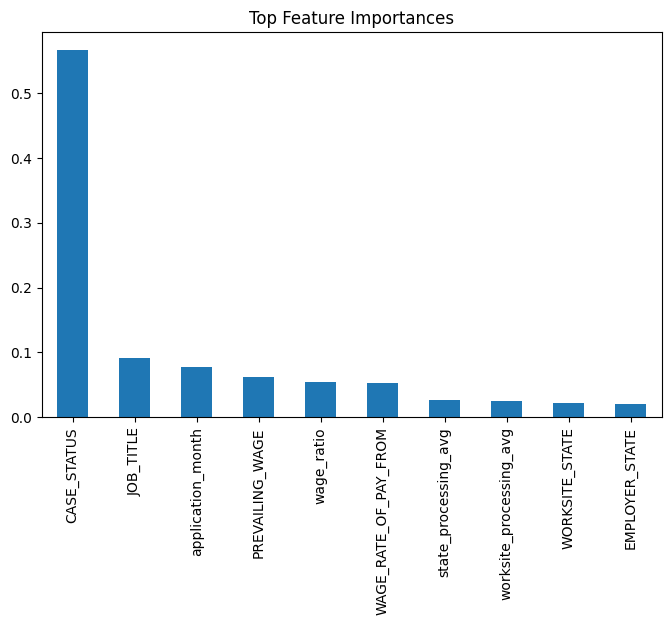

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.head(10).plot(kind='bar')
plt.title("Top Feature Importances")
plt.show()

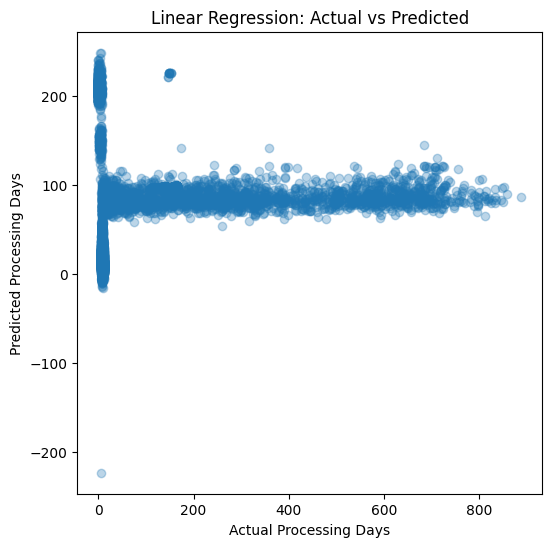

In [13]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lr, alpha=0.3)

plt.xlabel("Actual Processing Days")
plt.ylabel("Predicted Processing Days")

plt.title("Linear Regression: Actual vs Predicted")

plt.show()

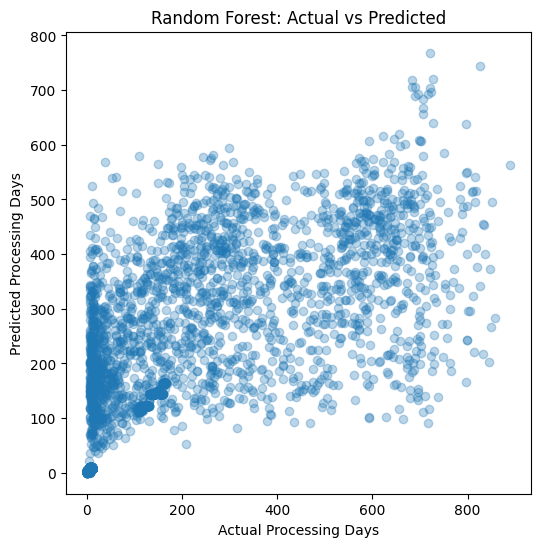

In [14]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf, alpha=0.3)

plt.xlabel("Actual Processing Days")
plt.ylabel("Predicted Processing Days")

plt.title("Random Forest: Actual vs Predicted")

plt.show()

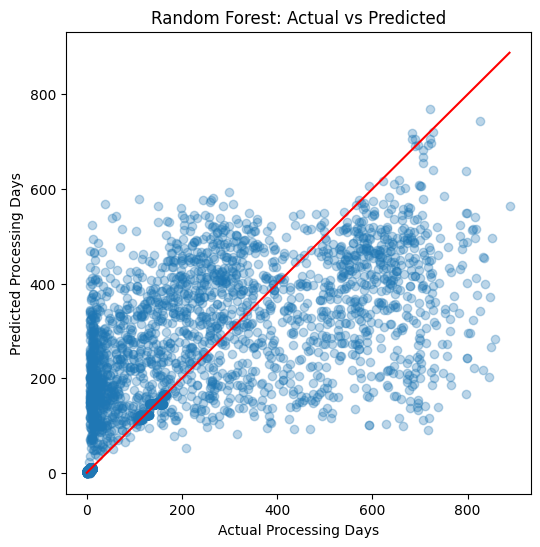

In [15]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf, alpha=0.3)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Processing Days")
plt.ylabel("Predicted Processing Days")

plt.title("Random Forest: Actual vs Predicted")

plt.show()

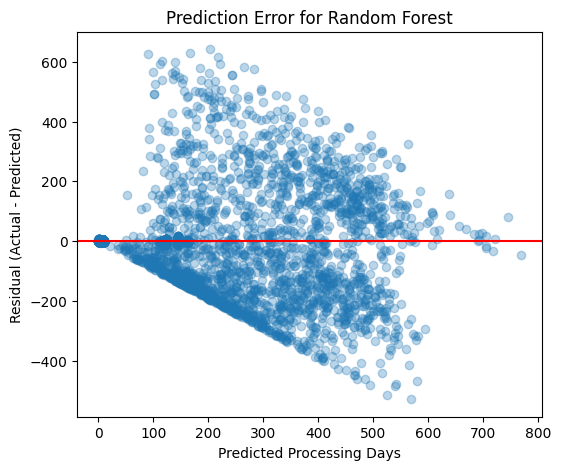

In [16]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(6,5))

plt.scatter(y_pred_rf, residuals, alpha=0.3)

plt.axhline(0, color='red')

plt.xlabel("Predicted Processing Days")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Prediction Error for Random Forest")

plt.show()

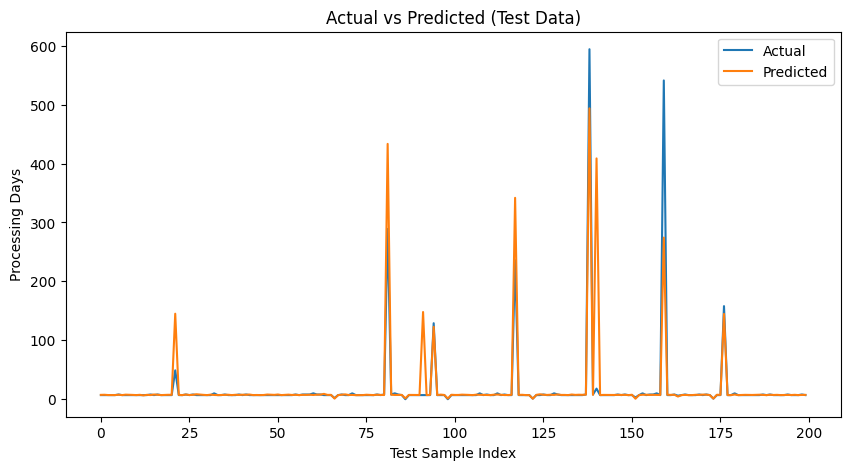

In [17]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred_rf[:200], label="Predicted")

plt.legend()

plt.xlabel("Test Sample Index")
plt.ylabel("Processing Days")
plt.title("Actual vs Predicted (Test Data)")

plt.show()

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [19]:
param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 3]
}

In [20]:
rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [ ]:
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)